# Sales Performance Analysis — Alfido Tech
**Intern Spark | Data Analyst Internship Project**

**Dataset:** [Superstore Sales (Kaggle)](https://www.kaggle.com/datasets/bhanupratapbiswas/superstore-sales)
**Prepared by:** Data Analyst Intern
**Objective:** Analyze sales performance across regions, categories, and time; identify best/worst performing products and seasonality; suggest tactical improvements for Alfido Tech.

---

### Contents
1. [Setup & Data Loading](#1)
2. [Data Cleaning & Preparation](#2)
3. [KPIs](#3)
4. [Category, Sub-Category & Product Performance](#4)
5. [Regional & Segment Performance](#5)
6. [Trends & Seasonality](#6)
7. [Order Value & Shipping](#7)
8. [Key Findings](#8)
9. [Tactical Recommendations for Alfido Tech](#9)


## 1. Setup & Data Loading <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', 20)

COLOR_PRIMARY = "#2C6E8F"
COLOR_ACCENT  = "#E8A23D"
PALETTE = ["#2C6E8F", "#E8A23D", "#5B8C5A", "#C15A5A", "#7C6BA6", "#4FA8A0"]

%matplotlib inline

In [2]:
df = pd.read_csv("archive_extracted/superstore_final_dataset (1).csv", encoding='latin1')
print("Shape:", df.shape)
df.head()

Shape: (9800, 18)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   str    
 2   Order_Date     9800 non-null   str    
 3   Ship_Date      9800 non-null   str    
 4   Ship_Mode      9800 non-null   str    
 5   Customer_ID    9800 non-null   str    
 6   Customer_Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product_ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub_Category   9800 non-null   str    
 16  Product_Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

## 2. Data Cleaning & Preparation <a id='2'></a>

Checks performed:
- Missing values & duplicates
- Date parsing (format verification)
- Referential sanity: Ship_Date should never precede Order_Date
- Derived fields: shipping delay, year/month/quarter periods


In [4]:
df.isna().sum()

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

`Postal_Code` is missing for 11 rows, all **Burlington, Vermont**. This is a single real city/state combination — we fill it with Burlington, VT's actual ZIP code (05401) rather than dropping the rows.

In [5]:
df[df['Postal_Code'].isna()][['City', 'State']].drop_duplicates()

,City,State
2234,Burlington,Vermont


In [6]:
df.loc[(df['City'] == 'Burlington') & (df['State'] == 'Vermont'), 'Postal_Code'] = 5401
df['Postal_Code'] = df['Postal_Code'].astype(int)
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


**Date format check:** the raw `Order_Date`/`Ship_Date` strings are ambiguous (e.g. `15/04/2018` could be day- or month-first). Since day values above 12 appear in the first position (e.g. `15/04/2018`), the format must be **day-first (DD/MM/YYYY)**. We verify this by confirming every `Ship_Date` falls on or after its `Order_Date` once parsed that way.

In [7]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], dayfirst=True)

assert (df['Ship_Date'] >= df['Order_Date']).all(), "Found ship dates before order dates - date parsing issue"
print("Date parsing verified: all ship dates occur on/after their order date.")
print("Date range:", df['Order_Date'].min().date(), "to", df['Order_Date'].max().date())

Date parsing verified: all ship dates occur on/after their order date.
Date range: 2015-01-03 to 2018-12-30


In [8]:
df['ShippingDelayDays'] = (df['Ship_Date'] - df['Order_Date']).dt.days
df['OrderYear'] = df['Order_Date'].dt.year
df['OrderMonth'] = df['Order_Date'].dt.to_period('M').dt.to_timestamp()
df['CalMonth'] = df['Order_Date'].dt.month

print("Sales <= 0:", (df['Sales'] <= 0).sum())
print("Unique orders:", df['Order_ID'].nunique())
print("Unique customers:", df['Customer_ID'].nunique())
df[['Sales', 'ShippingDelayDays']].describe()

Sales <= 0: 0
Unique orders: 4922
Unique customers: 793


,Sales,ShippingDelayDays
count,9800.000000,9800.000000
mean,230.769059,3.961122
std,626.651875,1.749614
min,0.444000,0.000000
25%,17.248000,3.000000
50%,54.490000,4.000000
75%,210.605000,5.000000
max,22638.480000,7.000000


**Note on scope:** this dataset variant contains `Sales` (revenue) but **no `Quantity`, `Discount`, or `Profit` columns**. This means profit margin and unit-based conversion metrics from the original task brief cannot be computed from this data — the analysis below focuses on revenue-based KPIs, and this limitation is called out explicitly rather than estimated or assumed.

## 3. Key Performance Indicators <a id='3'></a>

In [9]:
total_sales = df['Sales'].sum()
n_orders = df['Order_ID'].nunique()
n_line_items = len(df)
aov = df.groupby('Order_ID')['Sales'].sum().mean()
avg_line_value = df['Sales'].mean()
avg_ship_delay = df['ShippingDelayDays'].mean()

kpi = pd.DataFrame({
    'KPI': ['Total Revenue', 'Unique Orders', 'Line Items', 'Average Order Value',
            'Average Line-Item Value', 'Average Shipping Delay (days)', 'Unique Customers'],
    'Value': [f"${total_sales:,.0f}", f"{n_orders:,}", f"{n_line_items:,}", f"${aov:,.2f}",
              f"${avg_line_value:,.2f}", f"{avg_ship_delay:.2f}", f"{df['Customer_ID'].nunique():,}"]
})
kpi

,KPI,Value
0,Total Revenue,"$2,261,537"
1,Unique Orders,"4,922"
2,Line Items,"9,800"
3,Average Order Value,$459.48
4,Average Line-Item Value,$230.77
5,Average Shipping Delay (days),3.96
6,Unique Customers,793


## 4. Category, Sub-Category & Product Performance <a id='4'></a>

In [10]:
cat_perf = df.groupby('Category').agg(Revenue=('Sales', 'sum'), Orders=('Order_ID', 'nunique'),
                                       LineItems=('Sales', 'count')).sort_values('Revenue', ascending=False)
cat_perf

,Revenue,Orders,LineItems
Category,,,
Technology,827455.8730,1519,1813
Furniture,728658.5757,1727,2078
Office Supplies,705422.3340,3676,5909


In [11]:
subcat_perf = df.groupby('Sub_Category').agg(Revenue=('Sales', 'sum'), LineItems=('Sales', 'count'),
                                              AvgSale=('Sales', 'mean')).sort_values('Revenue', ascending=False)
subcat_perf

,Revenue,LineItems,AvgSale
Sub_Category,,,
Phones,327782.4480,876,374.180877
Chairs,322822.7310,607,531.833165
Storage,219343.3920,832,263.633885
Tables,202810.6280,314,645.893720
Binders,200028.7850,1492,134.067550
Machines,189238.6310,115,1645.553313
Accessories,164186.7000,756,217.178175
Copiers,146248.0940,66,2215.880212
Bookcases,113813.1987,226,503.598224


/tmp/ipykernel_570/2015104871.py:8: UserWarning: The palette list has more values (12) than needed (10), which may not be intended.
  sns.barplot(x=top_sub['Revenue'], y=top_sub.index, hue=top_sub.index, palette=PALETTE * 2, legend=False, ax=axes[1])


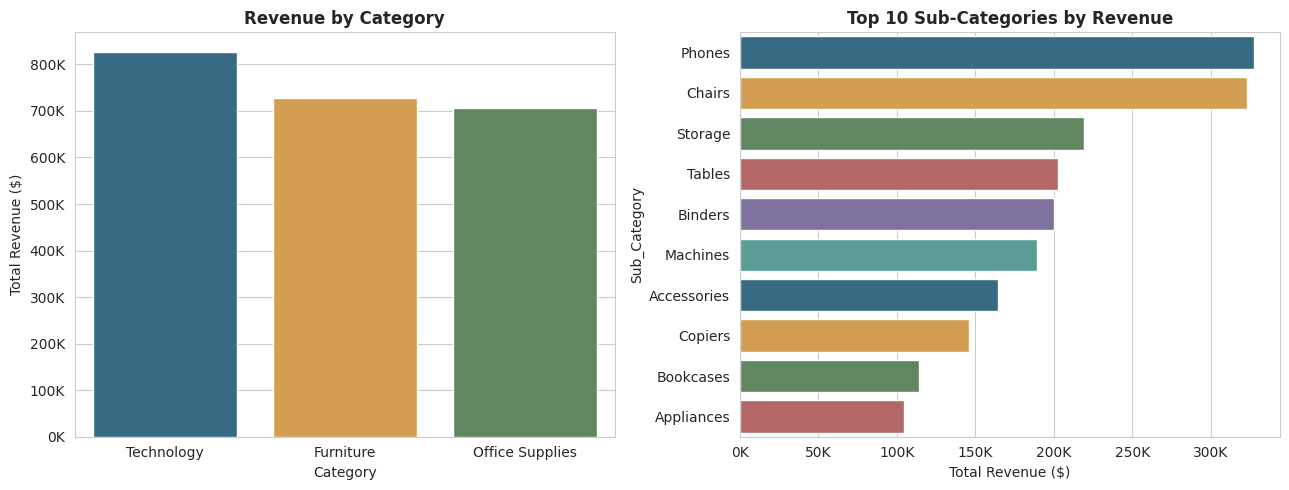

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x=cat_perf.index, y=cat_perf['Revenue'], hue=cat_perf.index, palette=PALETTE[:3], legend=False, ax=axes[0])
axes[0].set_title('Revenue by Category', fontweight='bold')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

top_sub = subcat_perf.head(10)
sns.barplot(x=top_sub['Revenue'], y=top_sub.index, hue=top_sub.index, palette=PALETTE * 2, legend=False, ax=axes[1])
axes[1].set_title('Top 10 Sub-Categories by Revenue', fontweight='bold')
axes[1].set_xlabel('Total Revenue ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

**Technology** narrowly leads on revenue despite having the fewest orders and line items of the three categories — its average sale size is much larger. **Phones**, **Chairs**, and **Storage** are the top revenue-generating sub-categories.

In [13]:
top_products = df.groupby('Product_Name').agg(Revenue=('Sales', 'sum'), LineItems=('Sales', 'count')).sort_values('Revenue', ascending=False)
print("Top 10 products by revenue:")
top_products.head(10)

Top 10 products by revenue:


,Revenue,LineItems
Product_Name,,
Canon imageCLASS 2200 Advanced Copier,61599.824,5
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,10
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,1
HON 5400 Series Task Chairs for Big and Tall,21870.576,8
GBC DocuBind TL300 Electric Binding System,19823.479,11
GBC Ibimaster 500 Manual ProClick Binding System,19024.500,9
Hewlett Packard LaserJet 3310 Copier,18839.686,8
HP Designjet T520 Inkjet Large Format Printer - 24 Color,18374.895,3
GBC DocuBind P400 Electric Binding System,17965.068,6


In [14]:
print("Lowest 10 products by revenue (min. 2 sales, to exclude one-off outliers):")
top_products[top_products['LineItems'] >= 2].sort_values('Revenue').head(10)

Lowest 10 products by revenue (min. 2 sales, to exclude one-off outliers):


,Revenue,LineItems
Product_Name,,
"Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink",7.800,2
Stockwell Gold Paper Clips,8.096,2
Acco Economy Flexible Poly Round Ring Binder,8.352,3
Newell 308,8.400,2
Kleencut Forged Office Shears by Acme United Corporation,9.568,2
Hoover Replacement Belt for Commercial Guardsman Heavy-Duty Upright Vacuum,9.768,4
"Alliance Big Bands Rubber Bands, 12/Pack",9.900,2
Letter Slitter,10.080,2
Newell 337,10.496,2


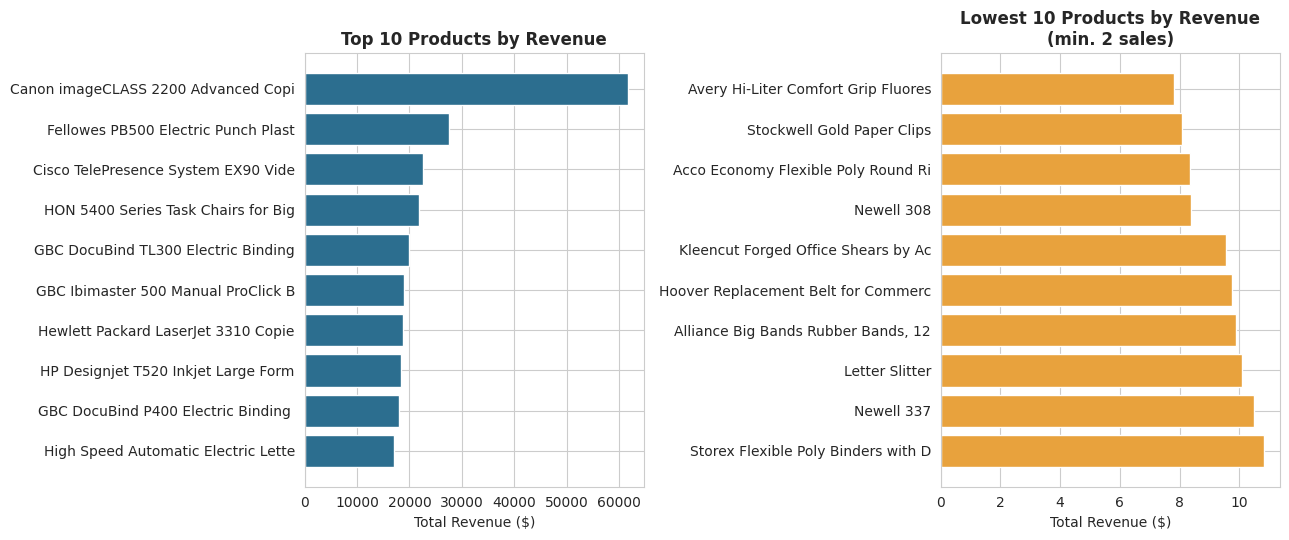

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
top10 = top_products.head(10).sort_values('Revenue')
axes[0].barh(top10.index.str.slice(0, 35), top10['Revenue'], color=COLOR_PRIMARY)
axes[0].set_title('Top 10 Products by Revenue', fontweight='bold')
axes[0].set_xlabel('Total Revenue ($)')

bottom10 = top_products[top_products['LineItems'] >= 2].sort_values('Revenue').head(10).sort_values('Revenue', ascending=False)
axes[1].barh(bottom10.index.str.slice(0, 35), bottom10['Revenue'], color=COLOR_ACCENT)
axes[1].set_title('Lowest 10 Products by Revenue\n(min. 2 sales)', fontweight='bold')
axes[1].set_xlabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

High-ticket technology items (copiers, video-conferencing systems, large-format printers) dominate the top-10 list — a handful of big-ticket sales drive outsized revenue. The bottom performers are all small office-supply accessories (highlighters, paper clips, rubber bands) selling for single-digit dollar amounts.

## 5. Regional & Segment Performance <a id='5'></a>

In [16]:
region_perf = df.groupby('Region').agg(Revenue=('Sales', 'sum'), Orders=('Order_ID', 'nunique')).sort_values('Revenue', ascending=False)
state_perf = df.groupby('State').agg(Revenue=('Sales', 'sum')).sort_values('Revenue', ascending=False)
region_perf

,Revenue,Orders
Region,,
West,710219.6845,1587
East,669518.7260,1369
Central,492646.9132,1156
South,389151.4590,810


/tmp/ipykernel_570/1942815409.py:8: UserWarning: The palette list has more values (12) than needed (10), which may not be intended.
  sns.barplot(x=top_states['Revenue'], y=top_states.index, hue=top_states.index, palette=PALETTE * 2, legend=False, ax=axes[1])


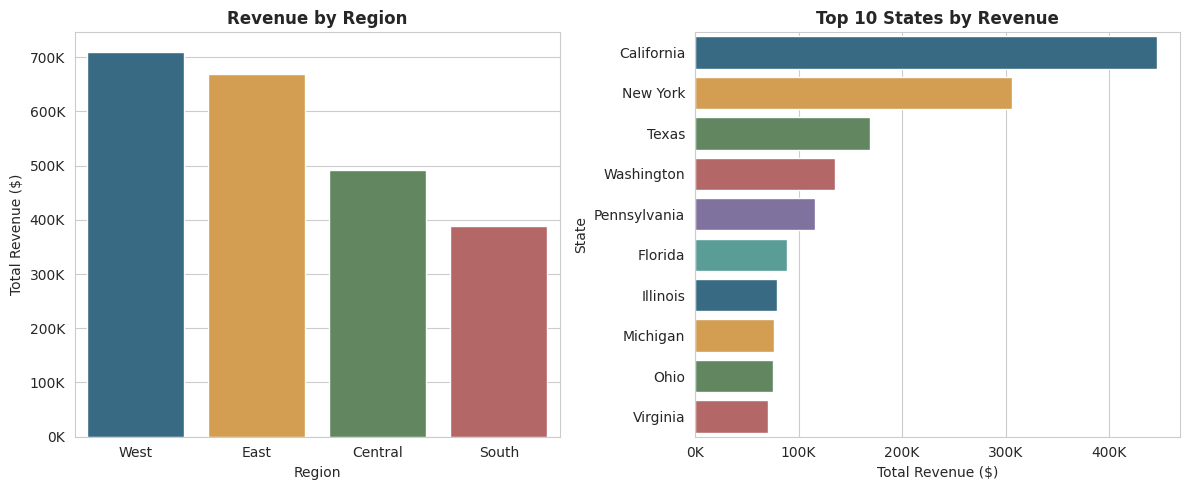

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=region_perf.index, y=region_perf['Revenue'], hue=region_perf.index, palette=PALETTE[:4], legend=False, ax=axes[0])
axes[0].set_title('Revenue by Region', fontweight='bold')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

top_states = state_perf.head(10)
sns.barplot(x=top_states['Revenue'], y=top_states.index, hue=top_states.index, palette=PALETTE * 2, legend=False, ax=axes[1])
axes[1].set_title('Top 10 States by Revenue', fontweight='bold')
axes[1].set_xlabel('Total Revenue ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

**West** and **East** regions generate the most revenue; **South** trails all other regions. **California** and **New York** alone account for a disproportionate share of total sales — together more than the entire South region.

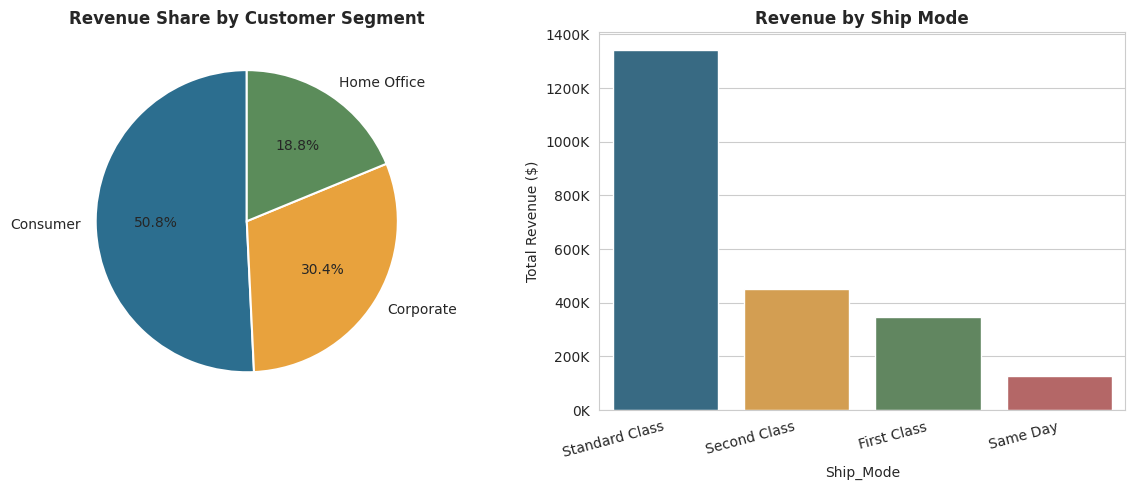

In [18]:
seg_perf = df.groupby('Segment').agg(Revenue=('Sales', 'sum'), Orders=('Order_ID', 'nunique')).sort_values('Revenue', ascending=False)
ship_perf = df.groupby('Ship_Mode').agg(Revenue=('Sales', 'sum')).sort_values('Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
seg_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
axes[0].pie(seg_sales.values, labels=seg_sales.index, autopct='%1.1f%%', colors=PALETTE, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Revenue Share by Customer Segment', fontweight='bold')

ship_sales = df.groupby('Ship_Mode')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=ship_sales.index, y=ship_sales.values, hue=ship_sales.index, palette=PALETTE[:4], legend=False, ax=axes[1])
axes[1].set_title('Revenue by Ship Mode', fontweight='bold')
axes[1].set_ylabel('Total Revenue ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

**Consumer** is by far the largest segment by revenue (~51%), roughly matching Corporate + Home Office combined. **Standard Class** shipping carries the majority of revenue, consistent with it being the default/cheapest option most customers choose.

## 6. Trends & Seasonality <a id='6'></a>

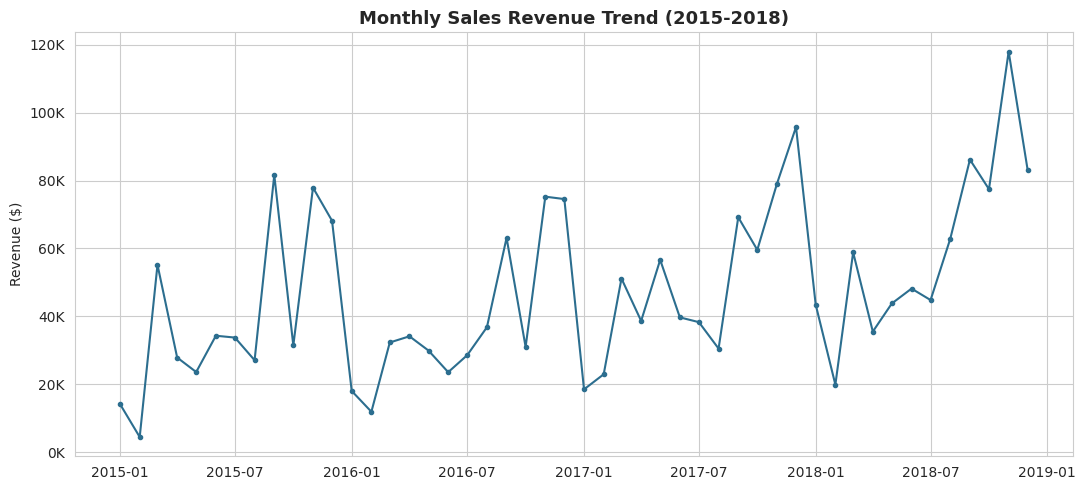

In [19]:
monthly = df.groupby('OrderMonth')['Sales'].sum()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly.index, monthly.values, color=COLOR_PRIMARY, marker='o', markersize=3)
ax.set_title('Monthly Sales Revenue Trend (2015-2018)', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

In [20]:
yearly = df.groupby('OrderYear')['Sales'].sum()
yearly_growth = yearly.pct_change() * 100
pd.DataFrame({'Revenue': yearly, 'YoY Growth %': yearly_growth.round(1)})

,Revenue,YoY Growth %
OrderYear,,
2015,479856.2081,NaN
2016,459436.0054,-4.3
2017,600192.5500,30.6
2018,722052.0192,20.3


Revenue grew every year in the dataset — from ~$480K in 2015 to ~$722K in 2018, a roughly 50% increase over four years, despite 2016 being essentially flat versus 2015.

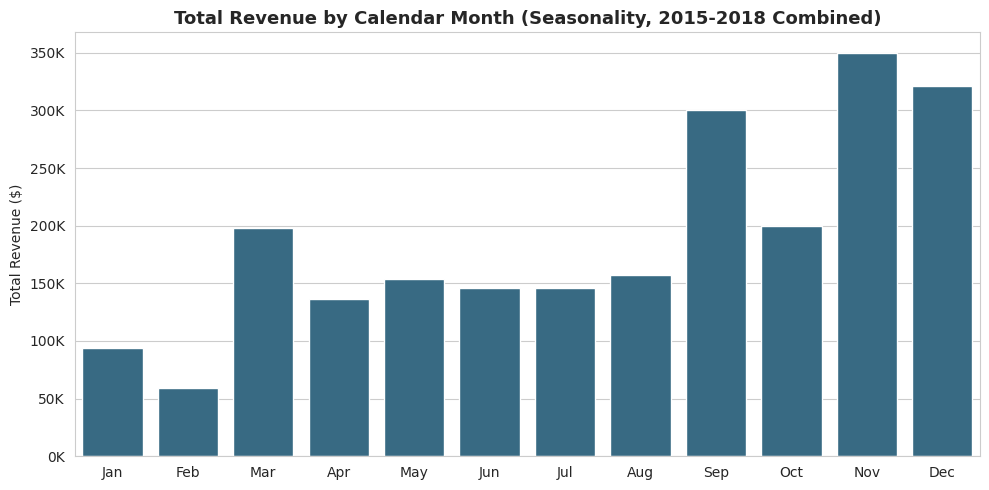

In [21]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
seasonality = df.groupby('CalMonth')['Sales'].sum()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=[month_names[m-1] for m in seasonality.index], y=seasonality.values, color=COLOR_PRIMARY, ax=ax)
ax.set_title('Total Revenue by Calendar Month (Seasonality, 2015-2018 Combined)', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

A clear seasonal pattern emerges every year: revenue climbs steadily from a **February low** to a **November peak** (roughly 6x February's revenue), stays strong through December, then drops sharply in January/February. September, November and December are consistently the strongest months — likely tied to back-to-school/fiscal year-end (Sep) and holiday season (Nov-Dec) purchasing.

## 7. Order Value & Shipping <a id='7'></a>

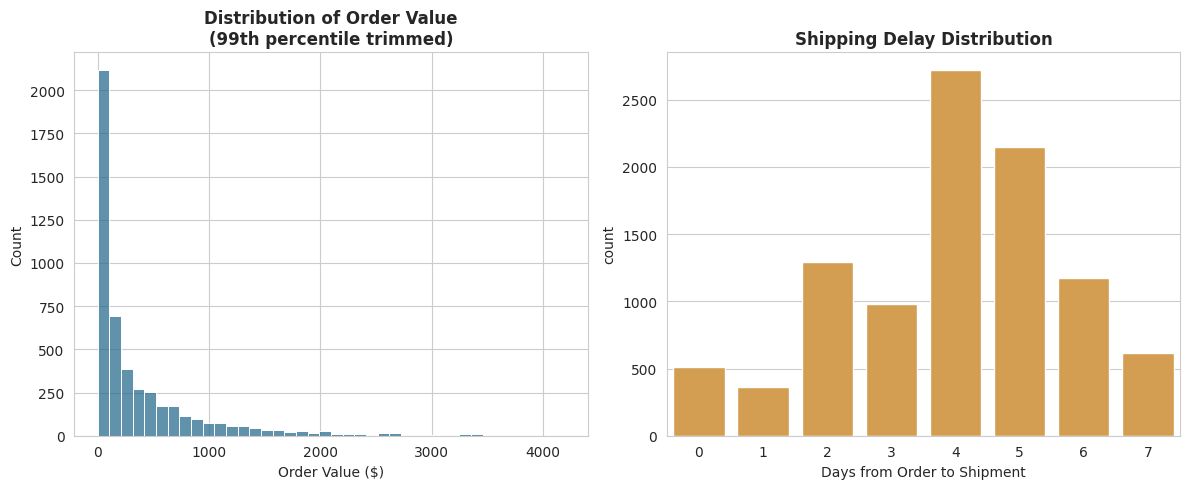

In [22]:
order_values = df.groupby('Order_ID')['Sales'].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(order_values[order_values < order_values.quantile(0.99)], bins=40, color=COLOR_PRIMARY, ax=axes[0])
axes[0].set_title('Distribution of Order Value\n(99th percentile trimmed)', fontweight='bold')
axes[0].set_xlabel('Order Value ($)')

sns.countplot(x='ShippingDelayDays', data=df, color=COLOR_ACCENT, ax=axes[1])
axes[1].set_title('Shipping Delay Distribution', fontweight='bold')
axes[1].set_xlabel('Days from Order to Shipment')
plt.tight_layout()
plt.show()

Most orders are modest in value, with a long right tail of large orders pulling the average up. Shipping delay is concentrated around 3-5 days, with a visible cluster at 0 days (same-day shipping) — consistent with the four `Ship_Mode` options in the data.

## 8. Key Findings <a id='8'></a>

1. **Total revenue is ~$2.26M** across 4,922 orders (9,800 line items) from 793 unique customers, Jan 2015 - Dec 2018, with an average order value of ~$459.
2. **Revenue grew every year**, from ~$480K (2015) to ~$722K (2018) — roughly 50% growth over four years, though 2016 was essentially flat vs. 2015.
3. **Strong, repeatable seasonality**: revenue bottoms out in February and peaks in November every year, with September and December also well above average — a clear planning signal for inventory and staffing.
4. **Technology leads on revenue despite fewer orders** — its average sale size is driven by high-ticket items (copiers, video conferencing systems, large-format printers) that dominate the top-10 product list.
5. **West and East regions outperform**; South lags all other regions, and California + New York alone generate more revenue than the entire South region combined.
6. **Consumer is the dominant segment** (~51% of revenue), and Standard Class is the dominant shipping mode.
7. **The dataset has no Quantity, Discount, or Profit fields**, so profitability and unit-economics questions (margin, discount impact, units sold) cannot be answered from this data — only revenue-based patterns are covered here.
8. Bottom-performing products are all **low-price office accessories** (highlighters, paper clips, rubber bands) selling for a few dollars each — a long tail of low-value SKUs.


## 9. Tactical Recommendations for Alfido Tech <a id='9'></a>

1. **Plan inventory and staffing around the Sep-Dec peak.** Revenue in November is roughly 6x February's — pre-building stock for high-velocity sub-categories (Phones, Chairs, Storage) ahead of Q3/Q4 and running February-March promotions to smooth the post-holiday trough would reduce both stockouts and idle-period revenue loss.

2. **Double down on Technology's high-ticket items.** Copiers, video-conferencing systems, and large-format printers punch far above their order-count weight. Bundling accessories/warranties with these items, or creating a "business upgrade" push targeting Corporate and Home Office segments, can extend this strength.

3. **Investigate the South region's underperformance.** South trails every other region despite the same product catalog. A closer look at store/rep coverage, marketing spend allocation, or local competition in Southern states could reveal a fixable gap rather than an inherent demand ceiling.

4. **Rationalize the long tail of low-value SKUs.** Products like highlighters, paper clips, and rubber bands generate single-digit-dollar revenue per sale. Consider bundling these into multi-packs or with higher-margin items, and evaluate whether some should be deprioritized in marketing/catalog placement in favor of higher-revenue sub-categories.

5. **Add profit and unit-level tracking to future data collection.** This dataset only captures revenue — without Quantity, Discount, or Profit fields, Alfido Tech cannot distinguish a highly profitable steady seller from a high-revenue, heavily-discounted one. Capturing these fields going forward would unlock true margin-based decision-making, not just topline revenue analysis.


---
### Notes on Methodology
- Dataset: 9,800 order line items / 4,922 unique orders / 793 unique customers, Jan 2015 - Dec 2018, from the Kaggle *Superstore Sales* dataset.
- Dates were parsed as day-first (DD/MM/YYYY) and verified by confirming every Ship_Date occurs on/after its Order_Date.
- This dataset variant excludes Quantity, Discount, and Profit — all findings and recommendations are based on **Sales (revenue)**, not profitability.
